<a href="https://colab.research.google.com/github/McEwan56/Data-Science-Project/blob/main/Semester_Project_McEwan_Bain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPSC 222 Data Science Semester Project - How TikTok Affects My Music Listening
By: McEwan Bain



## Introduction
This research project delves into my personal **TikTok Login History** and **Apple Music Listening History**. I obtained both data sets by requesting them from the respective companies that keep/store the revleveant data (Apple and TikTok). The **Apple Music** data was obtained as a .csv and the **TikTok** was originally a .json file that I converted into a .csv format.

I wanted to look at these two datasets because I was curious about how I use my phone and what kind of entertainment I prefered to use. Originally I thought the watch/listen statistics would be more similar, but we'll see soon that is not the case.

###The Datasets:
**Apple Music**:
Has 199 seperate instances of songs. Each instance has 26 seperate attributes.\
Notable attributes include:
- **Media duration in millis**: This is so I could see how long I was listening to music every day. The data comes in milliseconds, but I later convert to minutes for human readability
- **Num Listens**: An attribute I created by using a pivot table to count the number of songs that I listened to on a given day
- **Listened**: A attribiute I created that contains a 1 if I listened to any songs on a given day or a 0 if I did not

**TikTok**: This dataset had 7307 instances (logins) and 7 attributes, but I only used Date and Time from this set.\
Notable Attributes:
- **Num Logins**: An attribute I created by using a pivot table to count the number times I logged into TikTok on a given day
- **Login Succesful**: A attribiute I created that contains a 1 if I logined in to to TikTok on a given day or a 0 if I did not

**Common  Attributes to Both Data Sets:**
- **Date**: Attribute used to merge datasets
- **Time**: This is another attribite both sets have, its not something I would merge on but I thought it could be useful to look at wether time of day affects the usage of either my TikTok or Apple Music Listens

###Predictions:
**What I'm Trying to Predict**: How my TikTok usage affects the number of songs I listen to on a given day (Apple Music)

**Hypothesis**: The more TikToks I watch on a given day, the more likely I am to listen to more music on that same day.

While the information I learn from exploring this data may not affect anyone but me, I thought it would be intersting to look more closely at some of my habbits and see how much I really use my phone.




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

appleMusicData = pd.read_csv('drive/MyDrive/CPSC222/SemesterProject/AppleMusicHistory_Cleaned.csv')
tikTokData = pd.read_csv('drive/MyDrive/CPSC222/SemesterProject/tikTokLogins_Cleaned.csv')
tikTokData = tikTokData.drop(columns=['IP'])
display(appleMusicData)
display(tikTokData)

,Date,Time,Container Type,Container Description,Artist,Track Name,Ignore For Recommendations,Country,Container Reference,Track Reference,...,Last Event Received Timestamp,Last Event Start Timestamp,Max Event End Position in millis,Max Play Duration in millis,Media duration in millis,Media type,Min Event Start Position in millis,Total plays,Total skips,Total play duration in millis
0,10/2/2023,22:04:28,Playlist,Hype,Carly Rae Jepsen,Call Me Maybe,False,United States,256001025,1440874008,...,2023-10-03T02:49:45.017Z,2023-10-03T02:49:44.433Z,193400,108947,199835,AUDIO,0,1,0,193400
1,10/2/2023,0:05:03,Playlist,Hype,Jonathan Edwards,Sunshine (Go Away Today) [Single Version],False,United States,256001025,204675561,...,2023-10-03T16:16:33.495Z,2023-10-03T16:14:14.072Z,138733,138733,138733,AUDIO,0,3,1,292295
2,10/2/2023,0:03:23,NaN,NaN,Noah Kahan,False Confidence,False,United States,NaN,1459127574,...,2023-10-02T00:05:03.421Z,2023-10-02T00:04:57.505Z,10812,10812,223013,AUDIO,0,2,2,16139
3,10/2/2023,0:02:55,NaN,NaN,Jonathan Edwards,Sunshine (Go Away Today),False,United States,NaN,250153707,...,2023-10-02T00:04:57.332Z,2023-10-02T00:04:48.093Z,253405,61435,312800,AUDIO,0,1,1,106704
4,10/1/2023,19:13:38,NaN,NaN,YOASOBI,Into The Night (English Version),False,United States,NaN,1571239689,...,2023-10-01T19:13:39.960Z,2023-10-01T19:13:38.561Z,1221,1221,262153,AUDIO,0,1,1,1221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2/17/2023,19:50:59,Playlist,Hype,Ghost,Mary on a Cross,False,United States,256001025,1478932237,...,2023-09-28T03:55:59.859Z,2023-09-28T03:51:54.982Z,244854,244854,244804,AUDIO,0,99,30,18910837
196,2/17/2023,4:52:36,Playlist,Hype,X Ambassadors,Renegades,False,United States,256001025,1440816490,...,2023-10-03T16:14:09.163Z,2023-10-03T16:14:04.347Z,195554,195256,195200,AUDIO,0,63,20,9236094
197,2/16/2023,20:05:14,Playlist,Hype,Jeff Williams,"Red Like Roses, Pt. II (feat. Casey Lee Willi...",False,United States,256001025,785723974,...,2023-10-02T01:44:57.996Z,2023-10-02T01:40:55.195Z,242509,242509,242460,AUDIO,0,133,21,30393175
198,1/31/2023,1:20:58,Playlist,Hype,Juice WRLD & The Kid LAROI,Reminds Me of You,False,United States,256001025,1543080051,...,2023-09-26T23:35:32.406Z,2023-09-26T23:33:19.663Z,158081,158081,158032,AUDIO,0,155,52,18135213


,Date,Time,Time Zone,DeviceModel,DeviceSystem,NetworkType,Carrier
0,9/25/2023,22:32:17,UTC,"iPhone14,5",iOS 17.0.1,Wi-Fi,Verizon
1,9/25/2023,22:24:43,UTC,"iPhone14,5",iOS 17.0.1,Wi-Fi,Verizon
2,9/25/2023,22:22:16,UTC,"iPhone14,5",iOS 17.0.1,5g,Verizon
3,9/25/2023,22:12:26,UTC,"iPhone14,5",iOS 17.0.1,5g,Verizon
4,9/25/2023,22:10:44,UTC,"iPhone14,5",iOS 17.0.1,Wi-Fi,Verizon
...,...,...,...,...,...,...,...
7302,3/30/2023,3:41:43,UTC,"iPhone14,5",iOS 16.0,5g,Verizon
7303,3/30/2023,3:37:50,UTC,"iPhone14,5",iOS 16.0,5g,Verizon
7304,3/30/2023,3:36:22,UTC,"iPhone14,5",iOS 16.0,5g,Verizon
7305,3/30/2023,3:35:10,UTC,"iPhone14,5",iOS 16.0,5g,Verizon


The above code is used to import my two data sets and check that they have been imported properly by displaying them. The two data sets I will be looking at here in this project are Apple Music played tracks and my TikTok "login" history. At the moment of writing this I'm not exactly sure what is counted as a login, but I am looking into it.



Just from looking at the size of the datasets, I can see I've logged into tiktok far more often than I've played music.

##Data Cleaning and Exploration:


In [ ]:
tikTokData = tikTokData[tikTokData['Date'] >= '8/1/2023']
appleMusicData = appleMusicData[appleMusicData['Date'] >= '8/1/2023']

tikTokData['Login Success'] = 1
appleMusicData['Listened'] = 1

tikTokData = tikTokData.drop(columns=['DeviceSystem', 'DeviceModel'])
appleMusicData = appleMusicData.drop(columns=['Ignore For Recommendations','Last Event Start Timestamp', 'Max Event End Position in millis', 'Container Reference', 'Track Reference'])
appleMusicData = appleMusicData.drop(columns=['Feature Name', 'Last Event End Timestamp', 'Last Event Received Timestamp', 'Min Event Start Position in millis'])

# display(tikTokData)
# display(appleMusicData)

<ipython-input-267-87f3b8d3071f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tikTokData['Login Success'] = 1
<ipython-input-267-87f3b8d3071f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  appleMusicData['Listened'] = 1


Added a colum to both dataframes for purposes later when merging and plotting

Shortened up the lists to just include dates August 1st and onwards

Removed some attributes I don't think I'll need

Note that 1 = True



In [ ]:
## appleMusicData.plot(x='Date', y='Max Play Duration in millis')
## Ill redo this graph later after changing to minutes/seconds so I get a better visual

In [ ]:
numPerDayTikTok = tikTokData.pivot_table(index = ['Date'], aggfunc ='size')
numPerDayTikTok = numPerDayTikTok.reset_index()
numPerDayTikTok.columns = ['Date', 'Num Logins']

numPerDayAppleMusic = appleMusicData.pivot_table(index = ['Date'], aggfunc ='size')
numPerDayAppleMusic = numPerDayAppleMusic.reset_index()
numPerDayAppleMusic.columns = ['Date', 'Num Listens']

## display(numPerDayTikTok)
## display(numPerDayAppleMusic)

Here I counted the number of duplicate dates in each dataframe, and I graphed them as bar graphs below

In [ ]:
# numPerDayAppleMusic.plot(kind='bar', x='Date', y='Num Listens')

In [ ]:
# numPerDayTikTok.plot(kind='bar', x='Date', y='Num Logins')

Now lets merge both of those datframes into one and compare

In [ ]:
numPerDayBoth = numPerDayTikTok.merge(numPerDayAppleMusic, how='outer')
numPerDayBoth = numPerDayBoth.set_index('Date')
## display(numPerDayBoth)

In [ ]:
## numPerDayBoth.plot()
## hiding this b/c I get a better visual later on

Here I graphed the num logins and listens per day together

In [ ]:
tikTokShortened = tikTokData[['Date', 'Time', 'Login Success']]
appleMusicShortened = appleMusicData[['Date', 'Time', 'Media duration in millis', 'Listened']]

My tiktok data doesn't really have a good identifier as to what I'm watching which may end up being a little annoying.

Here I just clean up the data a little bit more, just for visualization purposes.

In [ ]:
mergedSets = appleMusicShortened.merge(tikTokShortened, how='outer', sort=True)
mergedSets = mergedSets.merge(numPerDayBoth, on='Date', how='outer')
mergedSets = mergedSets.set_index('Date')
display(mergedSets)

,Time,Media duration in millis,Listened,Login Success,Num Logins,Num Listens
Date,,,,,,
8/1/2023,0:19:39,NaN,NaN,1.0,70.0,1.0
8/1/2023,0:20:34,NaN,NaN,1.0,70.0,1.0
8/1/2023,0:25:12,NaN,NaN,1.0,70.0,1.0
8/1/2023,0:29:50,NaN,NaN,1.0,70.0,1.0
8/1/2023,0:33:25,NaN,NaN,1.0,70.0,1.0
...,...,...,...,...,...,...
9/9/2023,22:32:41,NaN,NaN,1.0,28.0,1.0
9/9/2023,22:35:14,181998.0,1.0,NaN,28.0,1.0
9/9/2023,23:54:54,NaN,NaN,1.0,28.0,1.0


I'm realizing here that maybe I didn't pick the best datasets to merge for this project, but we'll see where we can go from here.

In [ ]:
## mergedSets.plot(kind='box')

In [ ]:
# I have a lot of NaN values cuz when Im listening to songs i cant watch tiktok and vice verse, so im going to fill those nans with 0s
mergedSets = mergedSets.fillna(0)
# display(mergedSets)

<Axes: xlabel='Date'>

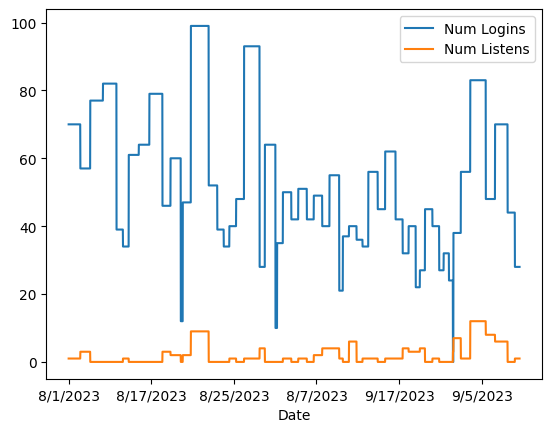

In [ ]:
compareDaysGraph = mergedSets[['Num Logins', 'Num Listens']]
compareDaysGraph.plot()

Just looking at the graphs and tables, it's pretty clear to me that I'm far more likely to login to tiktok than I am to listen to music. I didn't think the difference would be so dramatic but I guess I was wrong.


But what I am starting to see is that on days I listen to more music I also watch a lot more tiktoks

In [ ]:
## Here Im gonna convert milliseconds to minutes
import numpy as np

# creating a function to convert millisecond to minutes
def millis2Min(x):
  return np.divide(x, 60000)

millis = mergedSets['Media duration in millis']
minutes = millis.apply(millis2Min)

mergedSets = mergedSets.drop(columns = ['Media duration in millis'])
mergedSets['Duration in Minutes'] = minutes


Text(0.5, 0, 'Num Logins')

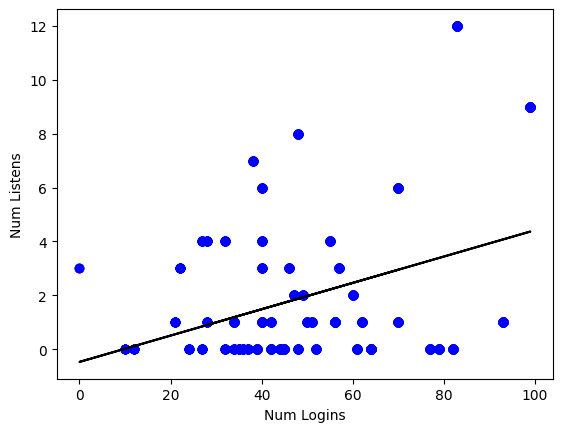

In [ ]:
# creating a simple linear regression model and seeing how they look
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

regressionData = mergedSets.dropna()
# defining an X and y
y = regressionData[['Num Listens']].values.reshape(-1, 1)
X = regressionData[['Num Logins']].values.reshape(-1, 1)

# Defining a linear model
linModel = LinearRegression()

#Fitting the Model
linModel.fit(X, y)

#Predictions
y_pred = linModel.predict(X)

## Graphing Data
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred,color='black')
plt.ylabel("Num Listens")
plt.xlabel("Num Logins")

We see here that there does in fact seem to be somewhat of a positive correlation between the number of logins and the number of listens, but it doesn't seem to be super strong or paritcularily accurate

### Summary of Data Cleaning:
I eneded up dropping a lot of attributes that I didn't need or couldn't figure out what to do with. Apple Music in particulat had a lot of attriubutes that didnt seem relevant or useful. There were a couple that may have been useful, but I had a hard time reading them or trying to figure out how to use them so I ended up droppin them. \
I also converted Milliseconds to seconds like I said I would. \
Had to deal with a lot of NaN's: I ended up dealing with them by replacing them with zeros (cant watch/listen to one if I'm listening to/watching the other). \
Because of the sheer amount of data, I also decided to cuttoff the data and only look at data collect on and after August 1st.

After all was said and done, I have a table with 2730 instances of info, and 6 attributes to work with.

This Data was actually a lot tougher to work with than I initally thought it would be. I don't have any good categorical data and the when I merged datasets I kind of just ended up with a boat load of NaNs. It was because due to the nature of my data, even though there were lots of shared dates, I couldn't just smash them together or I would a) lose out on a lot of data or b) have to many duplicates of data

###Summary of Data Exploration:
For Data Exploration I looked at a couple of different relationships. The one I really focused on was **Num Logins vs Num Listens**, but I also looked at **Duration vs Date**, and **Duration vs Num Logins**

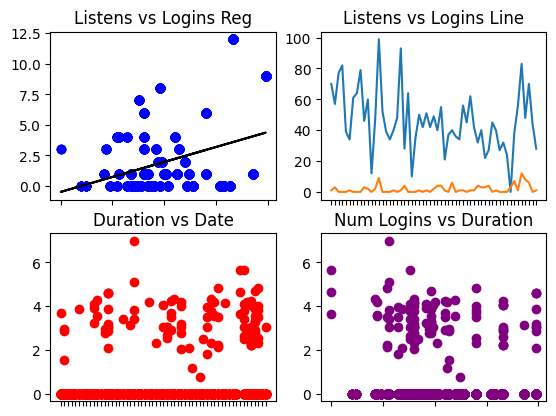

In [ ]:
## Here are some of the graphs that I feel helped visualize the above relationships the best
figure, axis = plt.subplots(2,2)
# Num Logins vs Num Listens

axis[0,0].scatter(X, y, color='blue')
axis[0,0].plot(X, y_pred,color='black')
axis[0,0].set_title("Listens vs Logins Reg")
axis[0,0].xaxis.set_tick_params(labelbottom=False)

axis[0,1].plot(compareDaysGraph)
axis[0,1].set_title("Listens vs Logins Line")
axis[0,1].xaxis.set_tick_params(labelbottom=False)

# Duration vs Date
X3 = mergedSets.index
y3 = mergedSets['Duration in Minutes']
axis[1,0].scatter(X3, y3, color='red')
axis[1,0].set_title("Duration vs Date")
axis[1,0].xaxis.set_tick_params(labelbottom=False)

# Duration vs Num Logins
X4 = mergedSets['Num Logins']
y4 = mergedSets['Duration in Minutes']
axis[1,1].scatter(X4, y4, color='purple')
axis[1,1].set_title("Num Logins vs Duration")
axis[1,1].xaxis.set_tick_params(labelbottom=False)

# Note that I decided to hide the X-axis labels. Even though you cant read what the values are,
# having them hidden makes the graphs look significantly better, and you can still get an idea of whats going on



As I stated earlier, these were just a couple of the graphs of relationships I looked at, at I feel like I can get the best results out of continuing to look at Listens vs Logins so thats the track I decided to continue exploring.

 \
After visualizing data, I realized that filling all the NaN's with 0 did lead to some problems with visualization. You can tell by looking at the large amount of '0 Duration' instances in the second set of graphs above. I still believe this was the right choice, especially for the attributes that I'm ending up comparing.

## Classification Models:


I decided to go ahead and use a KNN model to try to visualize and confirm my hypothesis


In [ ]:
#Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Initialize model
KnnClassifier = KNeighborsClassifier(n_neighbors=5)
# Split data
X = mergedSets[['Num Logins', 'Duration in Minutes']]
y = mergedSets[['Num Listens']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train model and make predictions for the test set.
KnnClassifier.fit(X_train_scaled, np.ravel(y_train))
y_pred = KnnClassifier.predict(scaler.transform(X_test))

test = pd.DataFrame(data={'Num Logins': [10], 'Duration in Minutes': [3]})
KnnClassifier.predict(scaler.transform(test))


array([4.])

In [ ]:
print(metrics.accuracy_score(y_pred, y_test))
print(metrics.confusion_matrix(y_pred, y_test))

0.8192918192918193
[[282  13   0   0  18   0   0   0   0   0]
 [ 12 145   2   3   1   2   0   1   0   0]
 [  0   0  57   1   1   0   0   0   0   0]
 [  0  24   0  57  10  16   0   0   0   0]
 [  0   7   0   1  27   1   0   0   0   0]
 [  0  13   0   0   0  23   1   0   0   0]
 [  0   0   0   1   0   0  10   0   0   0]
 [ 14   0   1   1   2   0   1  12   0   0]
 [  0   0   0   0   0   0   0   0  36   0]
 [  0   0   0   0   0   1   0   0   0  22]]


In [ ]:
from matplotlib.colors import ListedColormap
import seaborn as sns
# Define function for the plot.
#  X - two feature data frame,
#  y - output feature,
#  classifier - model that has been fit,
#  le - label encoder
#  with_data - plot the data with the regions


def plot_classification_regions(X, y, classifier, le, with_data=False):

    # Predict class on a regular grid

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X.iloc[:, 0].min() - 10, X.iloc[:, 0].max() + 10
    y_min, y_max = X.iloc[:, 1].min() - 10, X.iloc[:, 1].max() + 10
    xh = (x_max - x_min) / 200  # step size in the mesh for the x direction
    yh = (y_max - y_min) / 200  # step size in the mesh for the y direction

    xx, yy = np.meshgrid(np.arange(x_min, x_max, xh), np.arange(y_min, y_max, yh))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    # Get outputs ready for plotting
    Z = le.transform(Z)
    Z = Z.reshape(xx.shape)
    numClasses = len(le.classes_)
    # Plot the regions classified as different classes
    plt.figure(figsize=(8, 6))
    plt.contourf(
        xx,
        yy,
        Z,
        levels=[i - 0.5 for i in range(numClasses + 1)],
        cmap=ListedColormap(
            sns.color_palette("colorblind", as_cmap=False, n_colors=numClasses)
        ),
    )

    if with_data:
        p1 = sns.scatterplot(
            data=X,
            x=X.columns[0],
            y=X.columns[1],
            hue=le.transform(np.ravel(y)),
            palette="colorblind",
            alpha=1,
            edgecolor="black",
            style=le.transform(np.ravel(y)),
        )
        leg = p1.legend()
        leg.set_title("Variety")
        for t, l in zip(leg.texts, le.inverse_transform(range(7))):
            t.set_text(l)

In [ ]:
# Take a sample to keep runtime low while seeing what areas are classified as each bean
sampleLogins = mergedSets.sample(750, random_state=20220509)
sampleLogins.describe()

,Listened,Login Success,Num Logins,Num Listens,Duration in Minutes
count,750.000000,750.000000,750.000000,750.000000,750.000000
mean,0.036000,0.964000,55.028000,2.252000,0.121165
std,0.186414,0.186414,20.270415,3.086508,0.641333
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,40.000000,0.000000,0.000000
50%,0.000000,1.000000,51.000000,1.000000,0.000000
75%,0.000000,1.000000,70.000000,3.000000,0.000000
max,1.000000,1.000000,99.000000,12.000000,4.820267


In [ ]:
# Create a label encoder so colors match between plots
le = preprocessing.LabelEncoder()
le.fit(sampleLogins['Num Listens'])

# Define input and output features
y = sampleLogins[['Num Listens']]
X = sampleLogins[['Num Logins', 'Duration in Minutes']]

# Fit model
KnnClassifier.fit(X, np.ravel(y))

KNeighborsClassifier()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


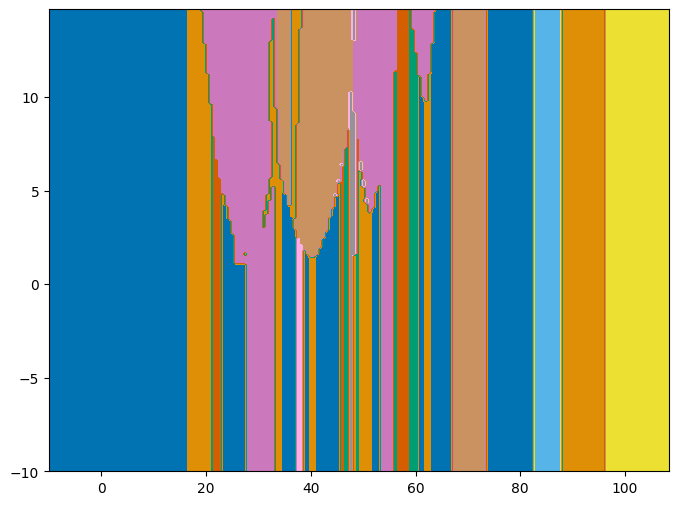

In [ ]:
plot_classification_regions(X, y, KnnClassifier, le, with_data=False)

Lets also try a decision tree classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import metrics, tree

# Split data
X = mergedSets[['Num Logins', 'Duration in Minutes']]
y = mergedSets[['Num Listens']]

# Initialize the model
classtreeModel = DecisionTreeClassifier(max_depth=2)

# Fit the model
classtreeModel = classtreeModel.fit(X, y)

# Print tree as text
print(export_text(classtreeModel, feature_names=X.columns.to_list()))

|--- Num Logins <= 96.00
|   |--- Num Logins <= 82.50
|   |   |--- class: 0.0
|   |--- Num Logins >  82.50
|   |   |--- class: 1.0
|--- Num Logins >  96.00
|   |--- class: 9.0



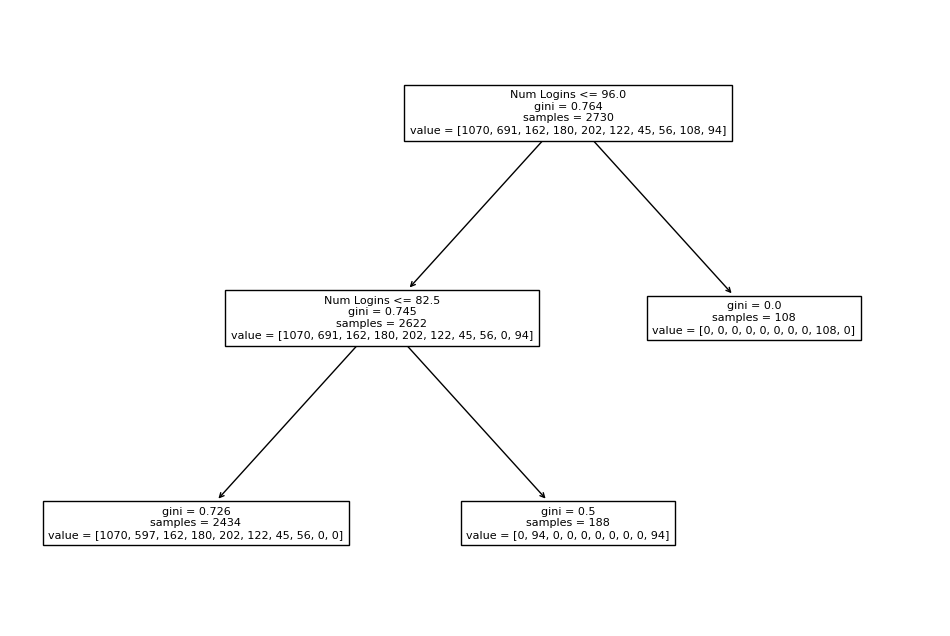

In [ ]:
# Resize the plotting window
plt.figure(figsize=[12, 8])

# Values in brackets represent classes
p = tree.plot_tree(classtreeModel, feature_names=X.columns, filled=False, fontsize=8)

Cross-entropy:  1.4707868945660625
Error rate:  0.5340659340659341


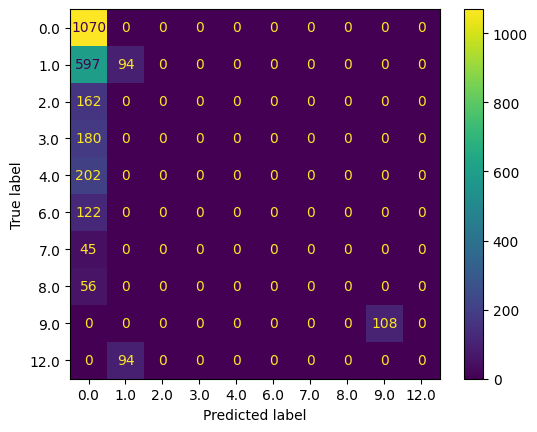

In [ ]:
# Calculate cross-entroy and error rate

print("Cross-entropy: ", metrics.log_loss(y, classtreeModel.predict_proba(X)))
print("Error rate: ", 1 - metrics.accuracy_score(y, classtreeModel.predict(X)))

# Calculate the confusion matrix
metrics.confusion_matrix(y, classtreeModel.predict(X))

# Plot the confusion matrix
metrics.ConfusionMatrixDisplay.from_predictions(y, classtreeModel.predict(X))

In [ ]:
# Calculate the Gini index
probs = pd.DataFrame(data=classtreeModel.predict_proba(X))

print("Gini index: ", (probs * (1 - probs)).mean().sum())

Gini index:  0.6820877013974853


###Summary of Classification Models:
I ended up doing both a decision tree classifer and a knn classifier to try and validate my hypothesis, but I ended up liking how the KNN classifer turned out a little better than the decision tree. \

Here I really realized how much choosing to fillna will 0 affected my results. I would have liked to drop all the nas, but that would have left me with no data to compare. Its just due to the way both of my datasets were structured and I dont think that I can change much about it. However if I were to do this project again, I would definetly pick different datasets to compare that work better together. But at least now I know what to look out for in the future. KNN also had a higher accuracy score so it just makes more sense to talk about that

 \
**KNN Classifer Results**: \
This bit is pretty cool to look at. I ended up trying to using both the number of logins ins and the duration of a song in minutes to try and predict the number of times I would listen to music in a given day. My **accuracy score** for the KNN classifier was ~0.8193 or about 81.93%.

But when we look at the graph, we get a little more idea of where the strengths and weakness of this Classifer lie. We see that the model is reall confident between about 0 and 16 logins and then it gets a little shaky before regaining confidence around the 70 Logins for the rest of the model.  

The confidence around the 0 area can be explained by the large amount of 0s I had in my dataset to fill the NaN's I had. Conversely I think the confidence up high is due to the lack of data I had nearing the 100 logins range. There were only a handful and I feel like that probably skewed the results.

The more shaky looking nature of the center of the graph is because thats where a majority of my data was located. I think it shows a better overall representation of my datasets.

##Conclusion
From what I've seen in analyzing my datasets using different graphs, linear regression, and classification models my hypothesis that as number of logins increase, so do the number of listens seems to be correct. There is clearly a positive relationship between the two and the various accuracy scores I got during testing range between 40-80%. But at the same time I feel like my results were heavily impacted by my use of fillna.

While my results kind of varried I think its cool that I was following somewhat of a pattern when it comes to my use of my phone. Looking back I would have liked to use different data sets, but I'm pretty proud of what I was able to do with what I had.